Thinking...
Thinking...

File metadata:
  Job: Seis
  Sample Rate: 1651.6129032258063
  Start Time: Tue Oct 01 2024 23:07:09 GMT-0700 (Pacific Daylight Time)


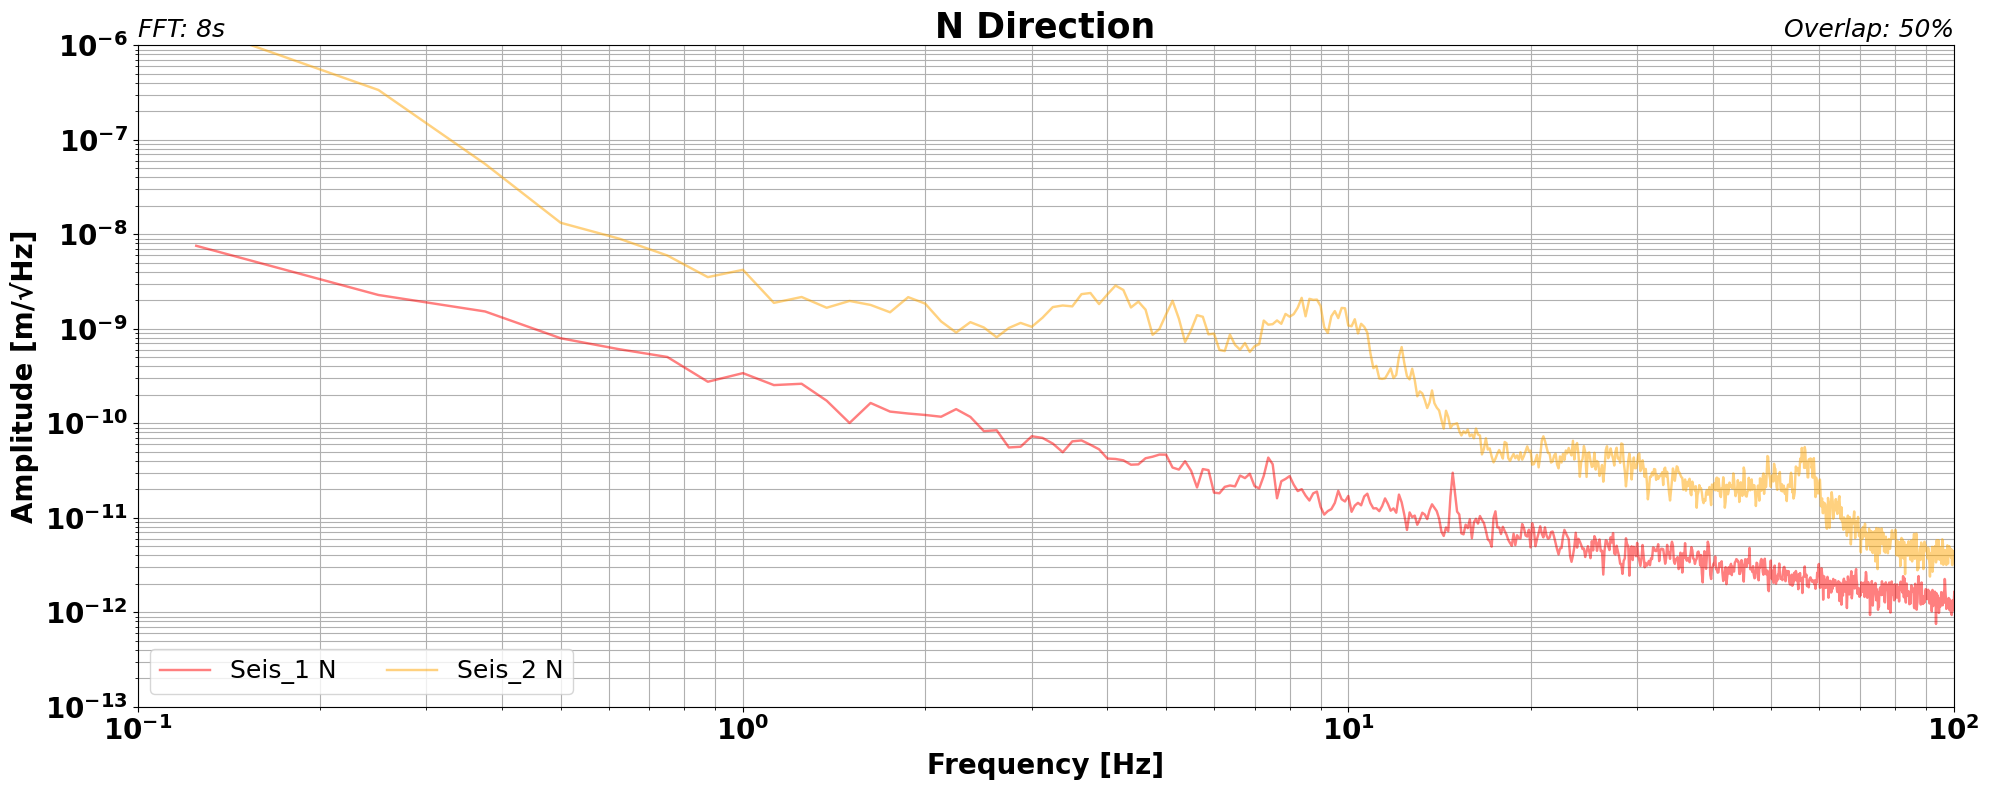

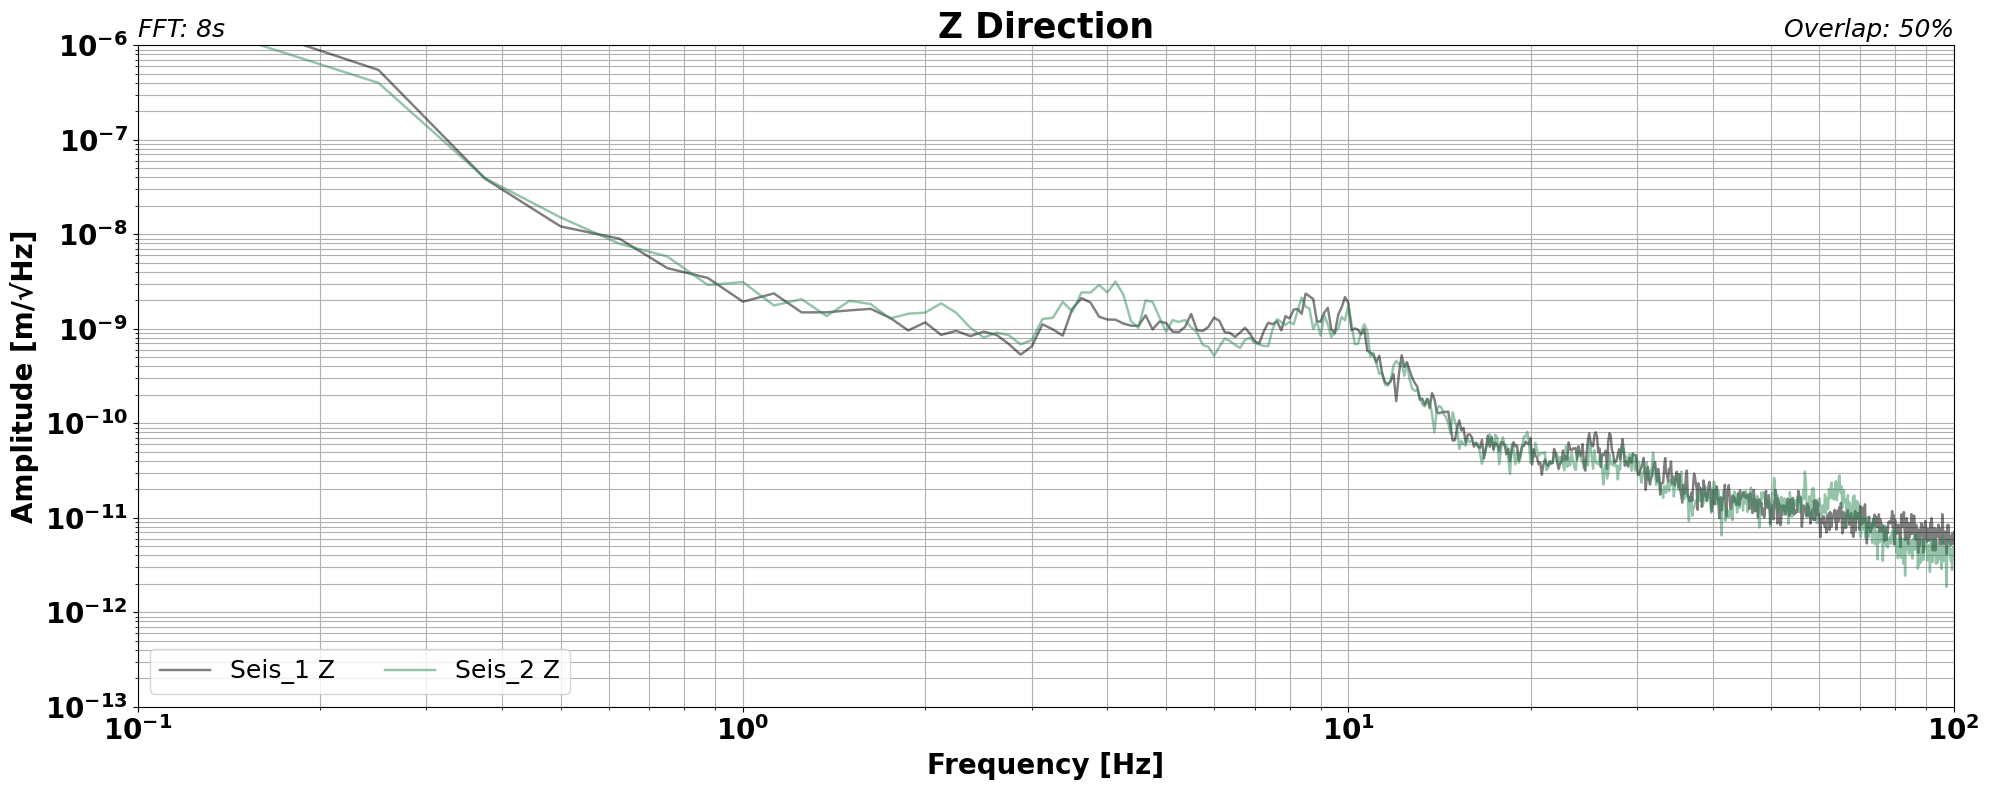

In [17]:
print("Thinking...")
import warnings
import pandas as pd                    # For reading CSV files into tables
import numpy as np                     # For numerical calculations
print("Thinking...")
from scipy import signal               # For the Welch PSD / spectral analysis
from matplotlib import pyplot as plt   # For creating plots
import os

warnings.simplefilter('ignore')

###--------------------------------------------------------------------------------------------------------------------------###
'''------------------------------------------------- SECTION 1 — FILE PATH --------------------------------------------------'''
###--------------------------------------------------------------------------------------------------------------------------###


## Set this to the location of your seismic CSV data file.

data_file_path = r"C:\Users\cacam\Documents\data_files\10-01-compare\seismo_test_cal_2024-10-01T22-07-09-752.csv"


###--------------------------------------------------------------------------------------------------------------------------###
'''----------------------------------------------- SECTION 2 — PLOT SETTINGS ------------------------------------------------'''
###--------------------------------------------------------------------------------------------------------------------------###


## Adjust these to control how the output plots look and how the FFT is computed.


# Y-axis (amplitude) range in m/√Hz or m·s⁻¹/√Hz:
y_max = 10e-7                                            # Top of the plot    (higher = more noise visible)
y_min = 10e-14                                           # Bottom of the plot (lower = more detail at quiet levels)


# X-axis (frequency) range in Hz:
x_max = 100                                              # Highest frequency to show
x_min = 0.1                                              # Lowest frequency to show


# FFT (spectral analysis) settings:
fft_length = 8                                           # Length of each FFT window in seconds
                                                         #   Longer = better frequency resolution, less time averaging

overlap    = 50                                          # Overlap between consecutive FFT windows, in percent (0–99)


# Were the pre-amplifiers used during recording?
pre_amps = False                                         # Set to True if pre-amps were active


###--------------------------------------------------------------------------------------------------------------------------###
'''------------------------------------------ SECTION 4 — READ THE FIELD DATA FILE ------------------------------------------'''
###--------------------------------------------------------------------------------------------------------------------------###


# --- Read metadata (first 5 lines) ---
metadata = {}
with open(data_file_path, 'r') as f:
    for _ in range(5):
        line = f.readline().strip()
        if ':' in line:
            key, value = line.split(':', 1)
            metadata[key.strip()] = value.strip()

print("\nFile metadata:")
for key, value in metadata.items():
    print(f"  {key}: {value}")

sample_rate = float(metadata["Sample Rate"])


# --- Read the seismic data columns ---
raw_data = pd.read_csv(data_file_path, skiprows=5, delimiter=',')
raw_data.columns = ["Sample", "Time (s)", 
                    "Seis_1 N", "Seis_1 Z", 
                    "Seis_2 N", "Seis_2 Z", "blank"]


# --- Apply calibration factor (Volts → meters per second) ---
if pre_amps:
    calibration = (0.0125e-1) / 21
else:
    calibration = 0.0125e-1

seis_1_n   = raw_data["Seis_1 N"] * calibration   # 
seis_1_z   = raw_data["Seis_1 Z"] * calibration   # 
seis_2_n   = raw_data["Seis_2 N"] * calibration   # 
seis_2_z   = raw_data["Seis_2 Z"] * calibration   # 


###--------------------------------------------------------------------------------------------------------------------------###
'''------------------------------------------- SECTION 6 — AXIS LABELS AND TITLES -------------------------------------------'''
###--------------------------------------------------------------------------------------------------------------------------###


plot_title_velocity     = "Seismic Velocity Data ASD"
plot_title_displacement = "Seismic Displacement Data ASD"
plot_titles             = {'z': "Z Direction",
                           'n': "N Direction",
                           'e': "E Direction"}

channel_titles_1        = {'z': "Seis_1 Z",
                           'n': "Seis_1 N",
                           'e': "Seis_1 E"}

channel_titles_2        = {'z': "Seis_2 Z",
                           'n': "Seis_2 N",
                           'e': "Seis_1 E"}

ylabel_velocity         = "Amplitude [ms⁻¹/√Hz]"
ylabel_displacement     = "Amplitude [m/√Hz]"


###--------------------------------------------------------------------------------------------------------------------------###
'''------------------------------------ SECTION 7 — ASD CALCULATION AND PLOTTING FUNCTION -----------------------------------'''
###--------------------------------------------------------------------------------------------------------------------------###


# Arguments:
#   data_vertical, data_north, data_east  — field data arrays (pass None to skip)
#   field_sample_rate                     — samples per second for field data
#   fft_window_s                          — FFT window length in seconds
#   y_min, y_max                          — amplitude axis limits
#   x_min, x_max                          — frequency axis limits
#   plot_type                             — 'velocity' or 'displacement'
#   channel                               — 'all', 'east', 'north', or 'zed'


def compute_and_plot_asd(seis1_z, seis1_n, seis1_e, seis2_z, seis2_n, seis2_e, field_sample_rate, 
                         overlap, fft_window_s, y_min, y_max, x_min, x_max, plot_type, channel):
    
    
    # ------------------- Inner helper: compute ASD for a single data array ---------------------- #
    
    def welch_asd(data, sr):
        """
        Run Welch's method on `data` sampled at `sr` Hz.
        Returns (frequencies, amplitude_spectral_density).
        """
        data = np.asarray(data)   # Ensure it's a plain numpy array

        frequencies, power = signal.welch(
            data,
            sr,
            window   = 'hamming',
            nperseg  = int(sr * fft_window_s),                  ## nperseg:  number of samples per FFT window
            noverlap = int(round(sr * (overlap * 0.01) ) )      ## noverlap: number of samples shared between adjacent windows
        )
        
        # ASD = square root of PSD
        return frequencies, np.sqrt(power)

    # -------------------------- Map channel keys to their data arrays --------------------------- #
    
    seis_1_channels = {'z': seis1_z,
                       'n': seis1_n,
                       'e': seis1_n}

    seis_2_channels = {'z': seis2_z,
                       'n': seis2_n,
                       'e': seis2_n}

    # ------------------------------------- Compute field ASDs ----------------------------------- #
    
    seis_1_results = {}

    for key, data in seis_1_channels.items():
        if data is None:
            continue   # Skip channels that weren't passed in

        freq, amp = welch_asd(data, field_sample_rate)

        if plot_type == 'displacement':
            
            # Convert velocity ASD → displacement ASD: divide by 2πf
            # (integrating in frequency domain)
            # Avoid division by zero at DC (freq = 0 Hz): set that bin to NaN
            
            disp = np.where(freq > 0, amp / (2 * np.pi * freq), np.nan)
        else:
            disp = None

        seis_1_results[key] = {'frequency': freq,
                               'amp':       amp,
                               'disp':      disp}

    # -------------------------------- Compute LIGO reference ASDs ------------------------------- #
    
    seis_2_results = {}

    for key, data in seis_2_channels.items():
        if data is None:
            continue

        freq, amp = welch_asd(data, field_sample_rate)

        if plot_type == 'displacement':
            disp = np.where(freq > 0, amp / (2 * np.pi * freq), np.nan)
        else:
            disp = None

        seis_2_results[key] = {'frequency': freq,
                               'amp':       amp,
                               'disp':      disp}

    # ------------------------ Decide which channels to include in this plot ---------------------- #
    
    
    channel_name_to_key = {'east':  'e',
                          'north':  'n',
                          'zed':    'z'}

    if channel == 'all':
        channels_to_plot = ['z', 'n', 'e']
        plot_title = plot_title_velocity if plot_type == 'velocity' else plot_title_displacement
        
    else:
        key = channel_name_to_key[channel]
        channels_to_plot = [key]
        plot_title = plot_titles[key]
        

    # ---------------------------------- Color coding per channel --------------------------------- #
    
    line_colors_1 = {'z': 'black',
                     'n': 'red',
                     'e': 'blue'}
    
    line_colors_2 = {'z': 'seagreen',
                     'n': 'orange',
                     'e': 'violet'}

    
    # --------------------------- Select y-axis label based on plot type -------------------------- #
    
    ylabel = ylabel_velocity if plot_type == 'velocity' else ylabel_displacement

    
    # ---------------------------------------- Draw the plot -------------------------------------- #
    
    plt.figure(figsize = (20, 8))
    plt.yscale('log')
    plt.xscale('log')

    for ch in channels_to_plot:
        if ch not in seis_1_results:
            continue

        # Choose velocity or displacement data for y-axis
        if plot_type == 'velocity':
            y_seis_1  = seis_1_results[ch]['amp']
            y_seis_2  = seis_2_results[ch]['amp']
        else:
            y_seis_1  = seis_1_results[ch]['disp']
            y_seis_2  = seis_2_results[ch]['disp']

        f_seis_1  = seis_1_results[ch]['frequency']
        f_seis_2  = seis_2_results[ch]['frequency']

        # Seis 1 data — solid line, channel color
        plt.plot(f_seis_1, y_seis_1,
                 color     = line_colors_1[ch],
                 linewidth = 1.75,
                 alpha     = 0.5,
                 label     = channel_titles_1[ch])

        # Seis 2 data — grey, semi-transparent
        plt.plot(f_seis_2, y_seis_2,
                 color     = line_colors_2[ch],
                 linewidth = 1.75,
                 alpha     = 0.5,
                 label     = channel_titles_2[ch])

    # --------------------------------------- Axis formatting ------------------------------------- #
    
    ax = plt.gca()

    
    plt.title(plot_title, fontweight = 'bold', fontsize = 25)
    plt.title(f'FFT: {fft_window_s}s', fontsize = 18, loc = 'left', style = 'italic')
    plt.title(f'Overlap: {overlap}%', fontsize = 18, loc = 'right', style = 'italic')

    plt.xlabel('Frequency [Hz]', fontweight = 'bold', fontsize = 20)
    plt.ylabel(ylabel,           fontweight = 'bold', fontsize = 20)
    
    plt.yticks(fontsize = 20, fontweight = 'bold')
    plt.xticks(fontsize = 20, fontweight = 'bold')

    
    ax.tick_params(axis = 'both', which = 'minor', labelsize = 16)
    for label in ax.get_yticklabels(which = 'minor'):
        label.set_fontweight('bold')
    for label in ax.get_xticklabels(which = 'minor'):
        label.set_fontweight('bold')

    plt.ylim(y_min, y_max)
    plt.xlim(x_min, x_max)

    plt.legend(loc = 'lower left', fontsize = 18, ncol = 2)
    plt.grid(True, which = 'both', ls = '-')
    plt.tight_layout()
    plt.show()


###--------------------------------------------------------------------------------------------------------------------------###
'''------------------------------------------------ SECTION 8 — RUN THE PLOTS -----------------------------------------------'''
###--------------------------------------------------------------------------------------------------------------------------###

# Shared keyword arguments to avoid repeating them three times
common_args = dict(
    field_sample_rate = sample_rate,
    overlap           = overlap,
    fft_window_s      = fft_length,
    y_min             = y_min,
    y_max             = y_max,
    x_min             = x_min,
    x_max             = x_max,
    plot_type         = "displacement"
)
'''
# ── All Channels (combined plot) — uncomment to enable ────────────────────────
compute_and_plot_asd(None, seis_1_n, , seis_2_n,seis_2_e
                     channel='all', **common_args)
'''


# ── North / East Channel ──────────────────────────────────────────────────────
compute_and_plot_asd(None, seis_1_n, None, None, seis_2_n, None,
                     channel = 'north', **common_args)

# ── Vertical (Z) Channel ──────────────────────────────────────────────────────
compute_and_plot_asd(seis_1_z, None, None, seis_2_z, None, None,
                     channel = 'zed', **common_args)